In [185]:
# Instalamos las dependencias necesarias para el proyecto

!python -m pip install pandas
!python -m pip install numpy
!python -m pip install scikit.learn
!python -m pip install matplotlib
!python -m pip install seaborn
!python -m pip install plotly
!python -m pip install -U nbformat


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [186]:
# Importamos los paquetes que luego se utilizarán. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [187]:
# Transformamos el dataset a un df y lo visualizamos para tener noción sobre qué hay dentro.
data = pd.read_csv("uber_fares.csv")
data.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [188]:
print(data.shape) # (fila, columna)          
print(data.dtypes) # Tipo de dato por columna

(200000, 9)
key                    int64
date                     str
fare_amount          float64
pickup_datetime          str
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object


Con esto podemos ver que hay 200.000 registros, cada uno con 9 columnas (['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']).

Además, vemos que 'date' y 'pickup_datetime' son str, esto lo modificaremos más adelante para un correcto uso de la información que poseen estas columnas.  

In [189]:
# Para iniciar la limpieza revisamos si hay datos duplicados. 

duplicados_totales = data.duplicated().sum()
duplicados_key = data["key"].duplicated().sum()

print("Duplicados totales:", duplicados_totales)
print("Duplicados en key:", duplicados_key)

vacios = data.isna().sum()

print(f"\n {vacios}")


Duplicados totales: 0
Duplicados en key: 0

 key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


Revisamos los duplicados tanto de los registros completos como de las key. Este último debido a que al ser el identificador de cada viaje, demostraría una inconsistencia en el dataset en caso de duplicados. 

También podemos ver que hay un viaje que no tiene dropoff_longitude ni dropoff_latitude, como si nunca hubiese terminado. Decidimos eliminarlo, ya que lo consideramos un dato que puede generar ruido en el modelo y no es significativo a la cantidad de registros. 

In [190]:
data = data.dropna()

In [191]:
pickup_sin_tz = data["pickup_datetime"].str.split(" ", n=2).str[:2].str.join(" ")
igualdad = (data["date"] == pickup_sin_tz).all()
print(f"¿Poseen los mismos datos en todos los registros? (True/False): {igualdad}")

data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"], errors="coerce")
data["date"] = pd.to_datetime(data["date"], errors="coerce")


¿Poseen los mismos datos en todos los registros? (True/False): True


Al comprobar que 'date' y 'pickup_datetime' poseen el mismo dato, con la diferencia de que la segunda tiene también la zona horaria, podemos proceder a eliminar date, para no tener información innecesariamente duplicada. 

In [192]:
data = data.drop(columns=["date"])

data["year"] = data["pickup_datetime"].dt.year
data["month"] = data["pickup_datetime"].dt.month
data["day"] = data["pickup_datetime"].dt.day
data["hour"] = data["pickup_datetime"].dt.hour
data["weekday"] = data["pickup_datetime"].dt.weekday
data["timezone"] = data["pickup_datetime"].dt.tz

data = data.drop(columns=["pickup_datetime"])

Separamos la información de 'pickup_datetime' en año, mes, día, hora, día de la semana y zona horaria para conservar la información de forma que sea utilizable luego. Al hacer esto decidimos eliminar la columna 'pickup_datetime' para no tener redundancias innecesarias. 

In [193]:
# Visualizamos como queda el df.
data.head()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,timezone
0,24238194,8.47,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,UTC
1,27835199,7.60,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,UTC
2,44984355,12.65,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,UTC
3,25894730,5.01,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,UTC
4,17610152,15.64,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,UTC


In [194]:
data.describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday
count,1.999990e+05,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,2.771248e+07,11.362851,-72.527631,39.935881,-72.525292,39.923890,1.684543,2011.742429,6.281841,15.704814,13.492617,3.048305
std,1.601386e+07,9.943232,11.437815,7.720558,13.117408,6.794829,1.385995,1.856395,3.438952,8.687419,6.513288,1.946946
min,1.000000e+00,1.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000
1%,5.539071e+05,2.950000,-74.014402,0.000000,-74.015288,0.000000,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000
5%,2.723432e+06,3.940000,-74.006838,40.701801,-74.007460,40.686410,1.000000,2009.000000,1.000000,2.000000,1.000000,0.000000
25%,1.382534e+07,5.970000,-73.992065,40.734796,-73.991407,40.733823,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000
50%,2.774524e+07,8.430000,-73.981823,40.752592,-73.980093,40.753042,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000
75%,4.155535e+07,12.660000,-73.967154,40.767158,-73.963658,40.768001,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000
95%,5.265729e+07,30.300000,-73.871199,40.787702,-73.874212,40.793744,5.000000,2015.000000,12.000000,29.000000,22.000000,6.000000


Viendo la salida del .describe() apreciamos valores extremos tanto de latitudes y longitudes, decidimos entonces eliminar todos los registros que tengan coordenadas no existentes, sea:

- latitud fuera de [-90, 90]
- longitud fuera de [-180, 180]
- valores 0, 0 o una de las coordenadas en 0

In [195]:
filtro_coords_validas = (
    data["pickup_latitude"].between(-90, 90) &
    data["dropoff_latitude"].between(-90, 90) &
    data["pickup_longitude"].between(-180, 180) &
    data["dropoff_longitude"].between(-180, 180)
)

data = data[filtro_coords_validas]

filtro_no_ceros = (
    (data["pickup_latitude"] != 0) &
    (data["pickup_longitude"] != 0) &
    (data["dropoff_latitude"] != 0) &
    (data["dropoff_longitude"] != 0)
)

data = data[filtro_no_ceros]

Vemos también que 'passenger_count' se puede ver que hay un viaje con más de doscientos pasajeros y algunos con cero, se asume que son errores de input, ya que la cantidad de pasajeros los ingresa el chofer, pero haremos un mejor estudio de los mismos y se determinará que hacer con ellos.

In [196]:
print(data["passenger_count"].value_counts().sort_index())

passenger_count
0         686
1      135635
2       28865
3        8708
4        4182
5       13740
6        4202
208         1
Name: count, dtype: int64


Que haya seis pasajeros, aunque sería incómodo a menos que se trate de un vehículo tipo SUV puede ser plausible, mientras que viajes con 0 o 200 son considerados un error en el dataset, y tambien eliminados para no comprometer la calidad del modelo.

Se consideró la posibilidad de que los viajes indicados con cero pasajeros sean envíos de paquetería, pero al no tener documentación que respalde esto decidimos no considerarlo. 

In [197]:
data = data[(data["passenger_count"] > 0) & (data["passenger_count"] <= 6)].copy()
print(data["passenger_count"].value_counts().sort_index())

passenger_count
1    135635
2     28865
3      8708
4      4182
5     13740
6      4202
Name: count, dtype: int64


Para comprender un poco mejor la distribución geográfica del dataset, se hará un mapa interactivo de los puntos de inicio y finalización de viajes. 

In [198]:
muestra = data.sample(20000, random_state=33).copy()

pickups = muestra[["pickup_latitude", "pickup_longitude"]].copy()
pickups.columns = ["lat", "lon"]
pickups["tipo"] = "Origen"

dropoffs = muestra[["dropoff_latitude", "dropoff_longitude"]].copy()
dropoffs.columns = ["lat", "lon"]
dropoffs["tipo"] = "Destino"

mapa_df = pd.concat([pickups, dropoffs], ignore_index=True)

fig = px.scatter_map(
    mapa_df,
    lat="lat",
    lon="lon",
    color="tipo",
    zoom=10,
    height=700,
    title="Puntos de inicio y finalización de los viajes",
    labels={"tipo": "Tipo de punto"},
    color_discrete_map={
        "Origen": "#00daff",
        "Destino": "#073D47"
        }
)

fig.update_layout(    
    map_style="open-street-map",
    title_x=0.5)
fig.show()

Observamos en el mapa dos situaciones que nos parece importante tener en consideración:

- Por un lado, la mayor concentración de viajes se encuentra dentro de Estados Unidos, principalmente al rededor de Nueva York. 
- Por otro, aun habiendo eliminado las coordenadas inexistentes, aparecen registros fuera del área geográfica de interés o ubicados sobre el océano, por lo que decidimos restringir el análisis a los viajes dentro de Estados Unido

Para continuar con este proyecto, nos quedaremos solo con los viajes dentro de Estados Unidos. 

In [199]:
exterior = data[
    ~(
        ((data["pickup_latitude"].between(24, 50))        &
         (data["pickup_longitude"].between(-125, -65)))   &
        ((data["dropoff_latitude"].between(24, 50))       &
         (data["dropoff_longitude"].between(-125, -65)))  
    )]
    
data = data.drop(exterior.index)

data.head()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,timezone
0,24238194,8.47,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,UTC
1,27835199,7.60,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,UTC
2,44984355,12.65,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,UTC
3,25894730,5.01,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,UTC
4,17610152,15.64,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,UTC


Consideramos que un dato importante que tener es la distancia recorrida en cada viaje, calculamos una estimación de esta distancia con la ecuación de Haversine.

In [200]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

data["distance_km"] = haversine_distance(
    data["pickup_latitude"],
    data["pickup_longitude"],
    data["dropoff_latitude"],
    data["dropoff_longitude"]
)

data.head()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,timezone,distance_km
0,24238194,8.47,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,UTC,1.683323
1,27835199,7.60,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,UTC,2.457590
2,44984355,12.65,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,UTC,5.036377
3,25894730,5.01,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,UTC,1.661683
4,17610152,15.64,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,UTC,4.475450


Realizamos a continuación los histogramas de las variables 'Tarifas' y 'Distancia' para ver sus distribuciones.

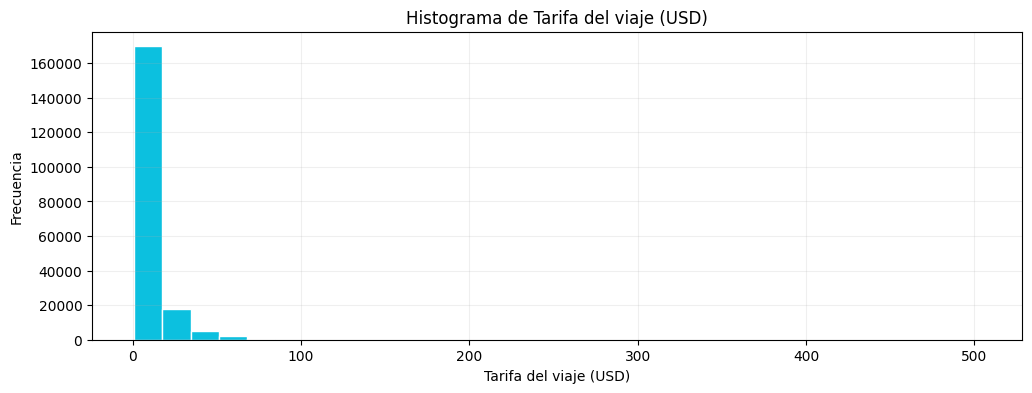

In [201]:
plt.figure(figsize=(12, 4))
data["fare_amount"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Tarifa del viaje (USD)")
plt.xlabel("Tarifa del viaje (USD)")
plt.ylabel("Frecuencia")
plt.show()

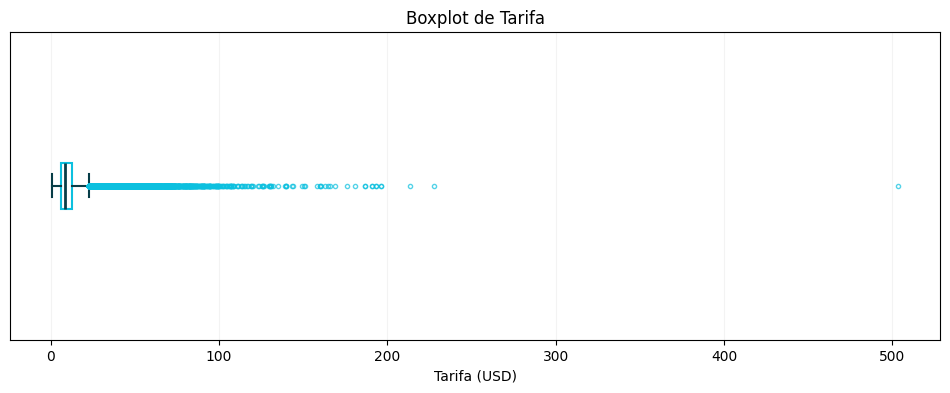

In [202]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["fare_amount"],
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", linewidth=1.5),
    medianprops=dict(color="#073D47", linewidth=2),
    whiskerprops=dict(color="#073D47", linewidth=1.5),
    capprops=dict(color="#073D47", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markeredgewidth=1,
        markersize=3,
        alpha=0.7
    )
)

plt.title("Boxplot de Tarifa")
plt.xlabel("Tarifa (USD)")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.show()

In [203]:
data["fare_amount"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count    195173.000000
mean         11.351422
std           9.854040
min           1.000000
1%            2.980000
5%            3.950000
25%           5.980000
50%           8.430000
75%          12.660000
95%          30.230000
99%          53.880000
max         503.130000
Name: fare_amount, dtype: float64

El boxplot de 'fare_amount' deja ver bastante bien que la mayoría de las tarifas se mueve en un rango bajo: la mediana es de 8.43 USD y el 75% de los viajes no pasa de 12.66 USD. Aun así, hay una cola superior bastante marcada, porque mientras el percentil 99 llega a 53.88 USD, el máximo se dispara hasta 503.13 USD. Esto sugiere que hay valores extremos que se alejan bastante del comportamiento general de la variable y que podrían ser atípicos. 

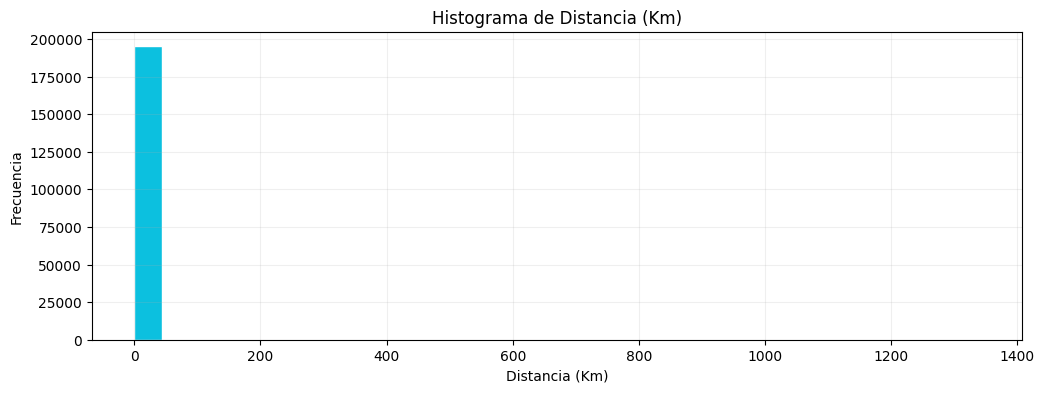

In [204]:
plt.figure(figsize=(12, 4))
data["distance_km"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Distancia (Km)")
plt.xlabel("Distancia (Km)")
plt.ylabel("Frecuencia")
plt.show()

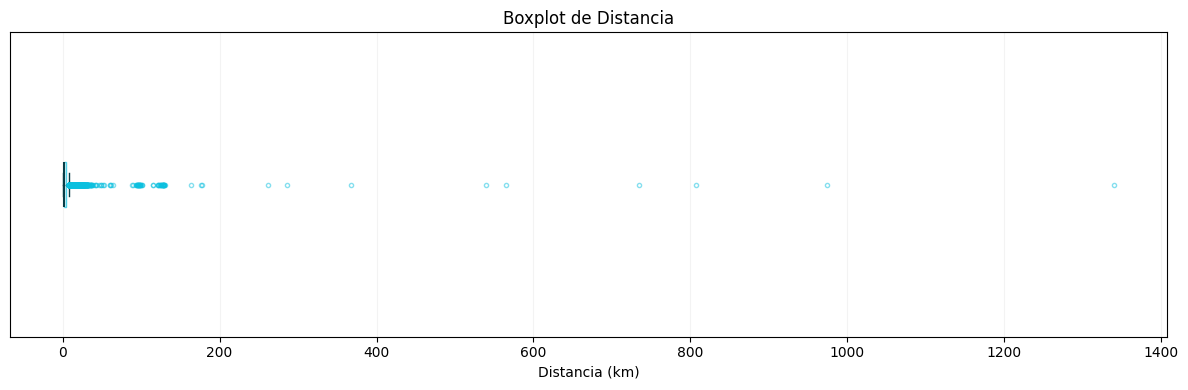

In [205]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["distance_km"],
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", alpha=0.7),
    medianprops=dict(color="#073D47", linewidth=1.5),
    whiskerprops=dict(color="#073D47"),
    capprops=dict(color="#073D47"),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markersize=3,
        alpha=0.5
    )
)

plt.title("Boxplot de Distancia")
plt.xlabel("Distancia (km)")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

In [206]:
data["distance_km"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

count    195173.000000
mean          3.376782
std           6.391574
min           0.000000
1%            0.000000
5%            0.561803
25%           1.255903
50%           2.157198
75%           3.909870
95%          10.022799
99%          20.401307
max        1340.106401
Name: distance_km, dtype: float64

En distance_km pasa algo parecido, pero todavía más marcado. La mediana es de 2.16 km y el 75% no supera los 3.91 km, así que la mayoría son trayectos cortos. Sin embargo, aparecen algunos valores muy alejados del resto: el percentil 99 está en 20.40 km, pero el máximo llega a 1340.11 km. Eso muestra una distribución muy sesgada hacia la derecha y la presencia de observaciones extremas que después va a ser importante revisar.

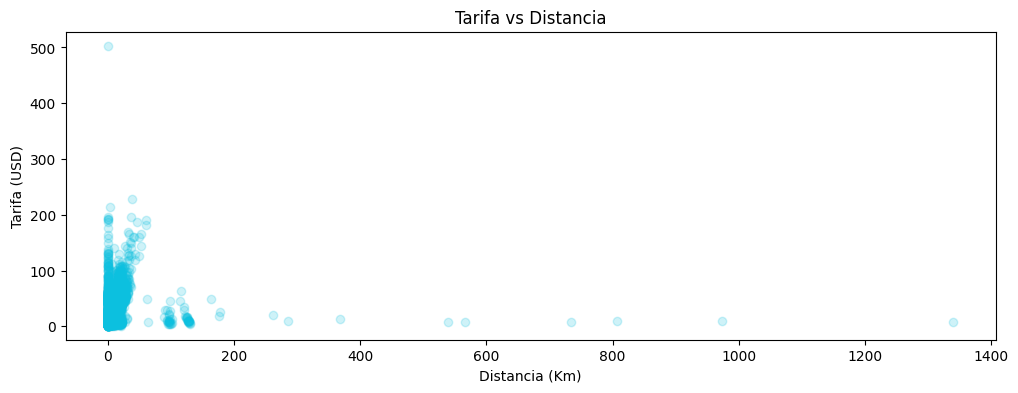

In [207]:
plt.figure(figsize=(12, 4))
plt.scatter(data["distance_km"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifa vs Distancia")
plt.xlabel("Distancia (Km)")
plt.ylabel("Tarifa (USD)")
plt.show()

Tanto en los boxplots como en el scatter plot se ve que fare_amount y distance_km tienen valores bastante alejados del comportamiento general. En particular, aparecen viajes muy cortos con tarifas inusualmente altas y también viajes muy largos con tarifas relativamente bajas. Como estos casos pueden influir demasiado en el análisis y en el ajuste del modelo, vamos a tomar los valores por encima del percentil 99.5 como potenciales outliers y los vamos a eliminar en estas variables.

In [208]:
columnas = ["fare_amount", "distance_km"]

for col in columnas:
    limite = data[col].quantile(0.995)
    data = data[data[col] <= limite]

A continuación, se muestran los gráficos una vez aplicado este recorte, para ver con más claridad cómo queda la distribución de los datos.

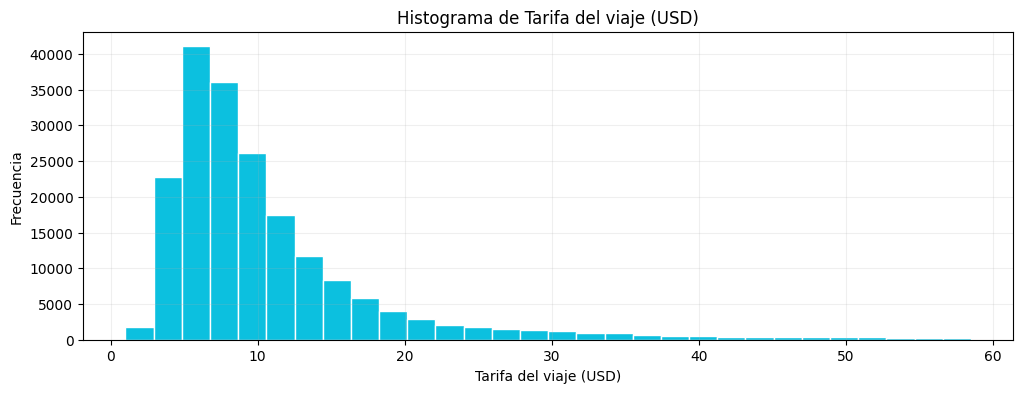

In [209]:
plt.figure(figsize=(12, 4))
data["fare_amount"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Tarifa del viaje (USD)")
plt.xlabel("Tarifa del viaje (USD)")
plt.ylabel("Frecuencia")
plt.show()

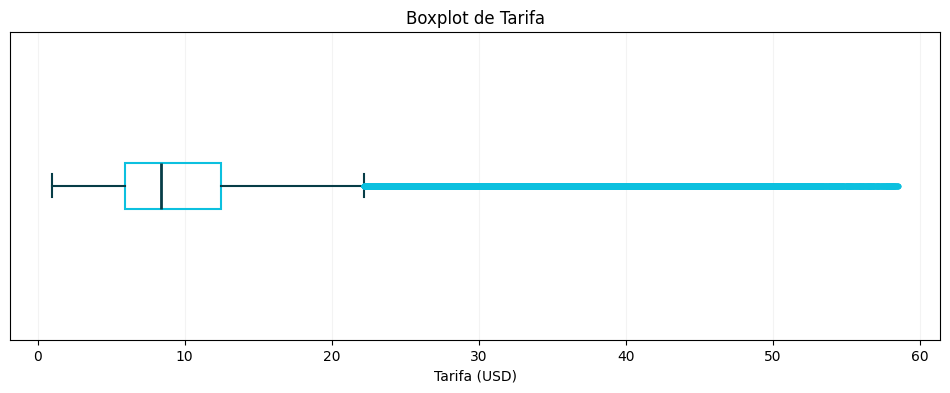

In [210]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["fare_amount"].dropna(),
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", linewidth=1.5),
    medianprops=dict(color="#073D47", linewidth=2),
    whiskerprops=dict(color="#073D47", linewidth=1.5),
    capprops=dict(color="#073D47", linewidth=1.5),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markeredgewidth=1,
        markersize=3,
        alpha=0.7
    )
)

plt.title("Boxplot de Tarifa")
plt.xlabel("Tarifa (USD)")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.show()

In [211]:
data["fare_amount"].describe(percentiles=[.25, .50, .75, .95, .99])

count    193226.000000
mean         10.853793
std           8.212946
min           1.000000
25%           5.960000
50%           8.370000
75%          12.460000
95%          27.750000
99%          47.840000
max          58.510000
Name: fare_amount, dtype: float64

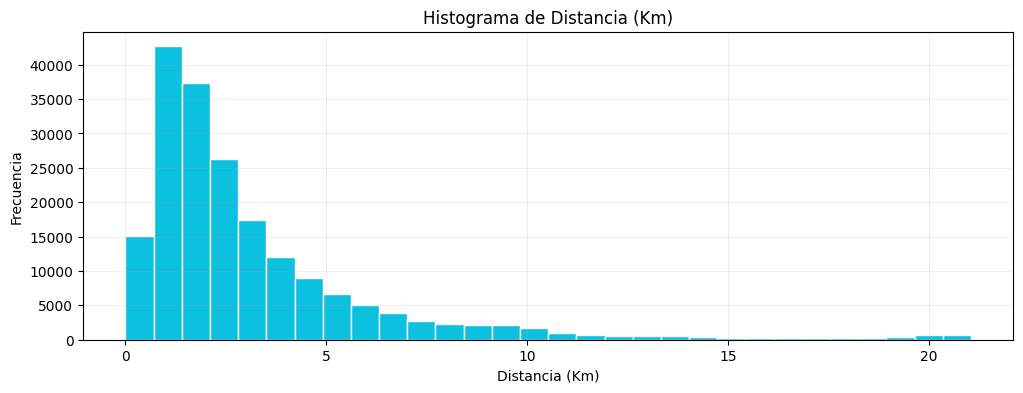

In [212]:
plt.figure(figsize=(12, 4))
data["distance_km"].hist(bins=30, color="#0cc0df", edgecolor="#FFFFFF")
plt.grid(True, alpha=0.2)
plt.title("Histograma de Distancia (Km)")
plt.xlabel("Distancia (Km)")
plt.ylabel("Frecuencia")
plt.show()

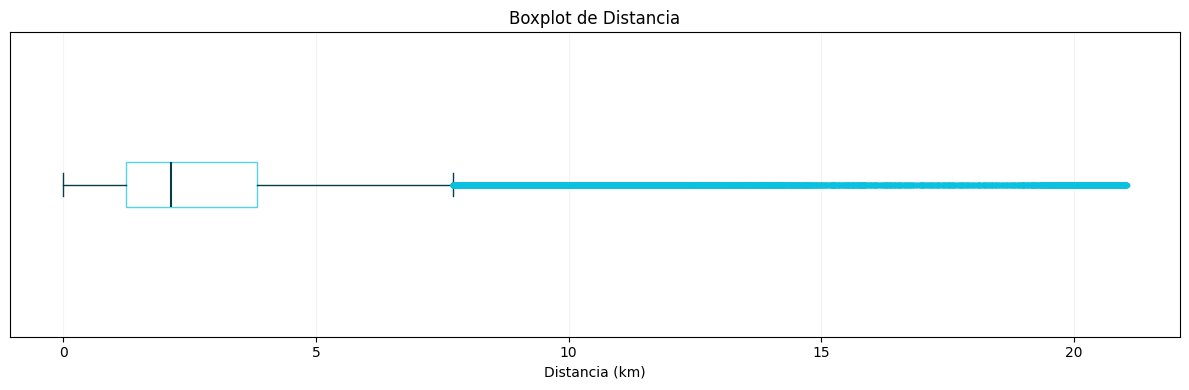

In [213]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    data["distance_km"],
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="#0cc0df", alpha=0.7),
    medianprops=dict(color="#073D47", linewidth=1.5),
    whiskerprops=dict(color="#073D47"),
    capprops=dict(color="#073D47"),
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="#0cc0df",
        markersize=3,
        alpha=0.5
    )
)

plt.title("Boxplot de Distancia")
plt.xlabel("Distancia (km)")
plt.yticks([])
plt.grid(True, axis="x", alpha=0.15)
plt.tight_layout()
plt.show()

In [214]:
data["distance_km"].describe(percentiles=[.25, .50, .75, .95, .99])

count    193226.000000
mean          3.159092
std           3.168786
min           0.000000
25%           1.249703
50%           2.138534
75%           3.833867
95%           9.430818
99%          18.211169
max          21.044396
Name: distance_km, dtype: float64

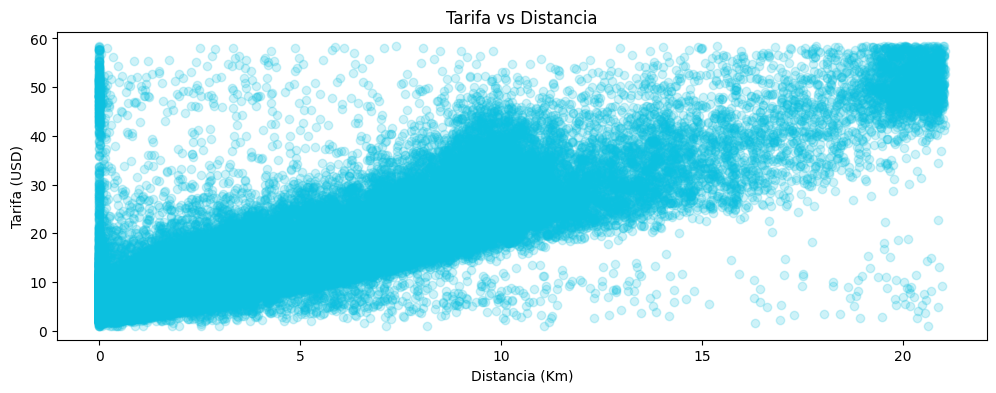

In [215]:
plt.figure(figsize=(12, 4))
plt.scatter(data["distance_km"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifa vs Distancia")
plt.xlabel("Distancia (Km)")
plt.ylabel("Tarifa (USD)")
plt.show()

En general, después del recorte los datos quedan bastante más ordenados y fáciles de interpretar. Se reduce la presencia de valores extremos que distorsionaban la visualización y algunas métricas descriptivas, pero se conserva la forma general de las distribuciones. Esto hace que el conjunto de datos resulte más adecuado para las etapas que siguen del trabajo.

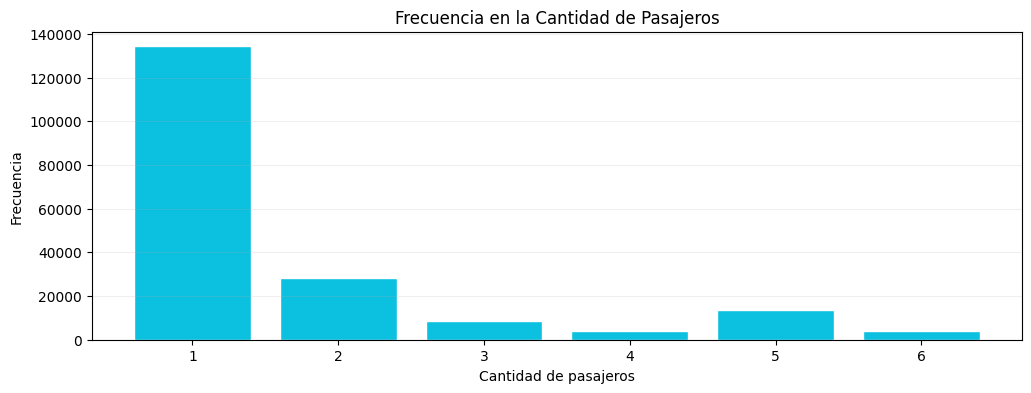

In [216]:
conteo = data["passenger_count"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Frecuencia en la Cantidad de Pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este gráfico podemos ver que hay una fuerte tendencia a los viajes individuales.

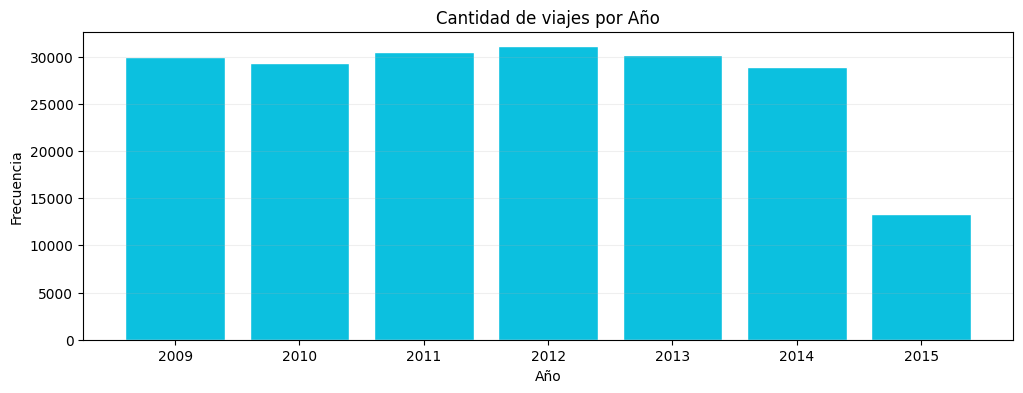

In [217]:
conteo = data["year"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por Año")
plt.xlabel("Año")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

El dataset contiene información hasta mediados del 2015, por lo que para las evaluaciones correspondientes a los meses vamos a usar una copia del dataset que solo tome hasta 2014, así evitamos distribuciones sesgadas por la falta de datos. 

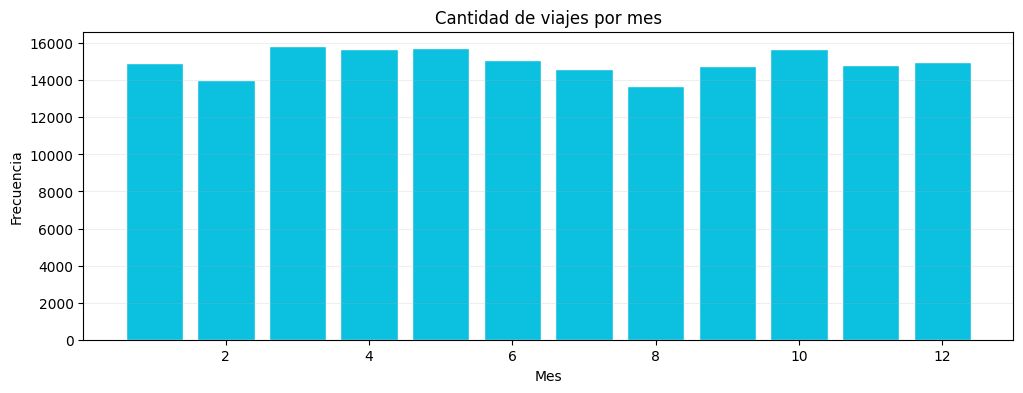

In [218]:
data_2014 = data[data["year"] < 2015].copy()

conteo = data_2014["month"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por mes")
plt.xlabel("Mes")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este gráfico se ve que la cantidad de viajes no se mantiene igual a lo largo del año, sino que va cambiando según el mes. Hay meses en los que la frecuencia sube y otros en los que baja, lo que nos da la idea de que puede haber cierta estacionalidad en los datos. De todas formas, con esta visualización sola no podemos asegurar a qué se debe esa variación, aunque sí nos permite ver que el mes podría estar capturando algún patrón temporal interesante dentro del comportamiento de los viajes.

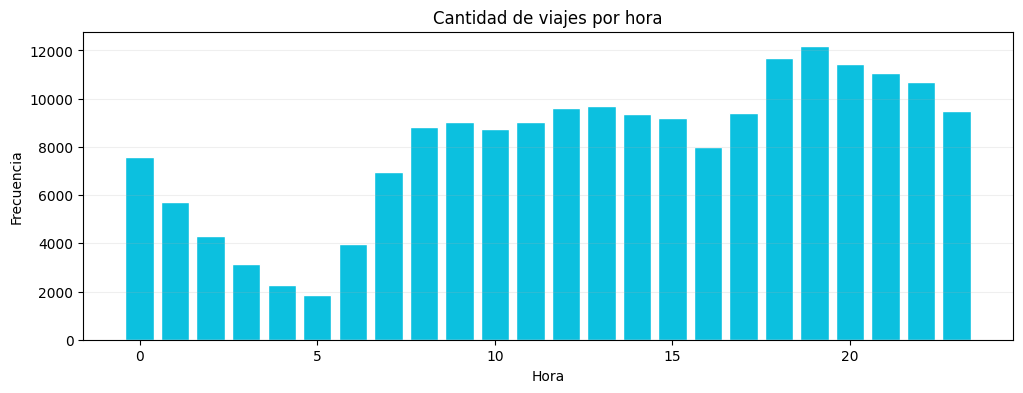

In [219]:
conteo = data["hour"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por hora")
plt.xlabel("Hora")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este gráfico nos muestra que durante la madrugada hay menos viajes, sobre todo entre las 3 y las 6 de la mañana. A partir de ahí la cantidad empieza a subir y se mantiene alta durante buena parte del día, con un pico más marcado hacia la tarde-noche, cerca de las 19 y 20 horas. Esto nos da la idea de que la demanda de viajes cambia según la hora, y que 'hour' puede ser una variable importante para el análisis.

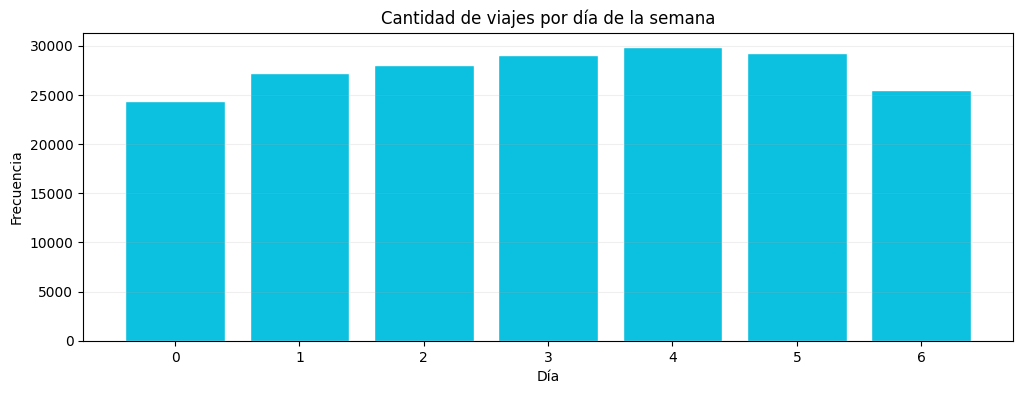

In [220]:
conteo = data["weekday"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.title("Cantidad de viajes por día de la semana")
plt.xlabel("Día")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

En este caso vemos que si bien los Lunes (Día 0) hay una frecuencia menor, la cantidad de viajes por día se mantiene mayormente estable. 

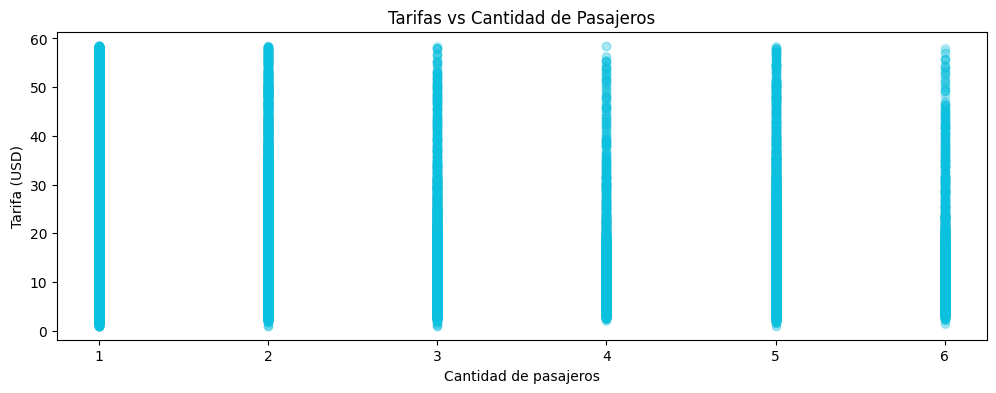

In [221]:
plt.figure(figsize=(12, 4))
plt.scatter(data["passenger_count"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifas vs Cantidad de Pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Tarifa (USD)")
plt.show()

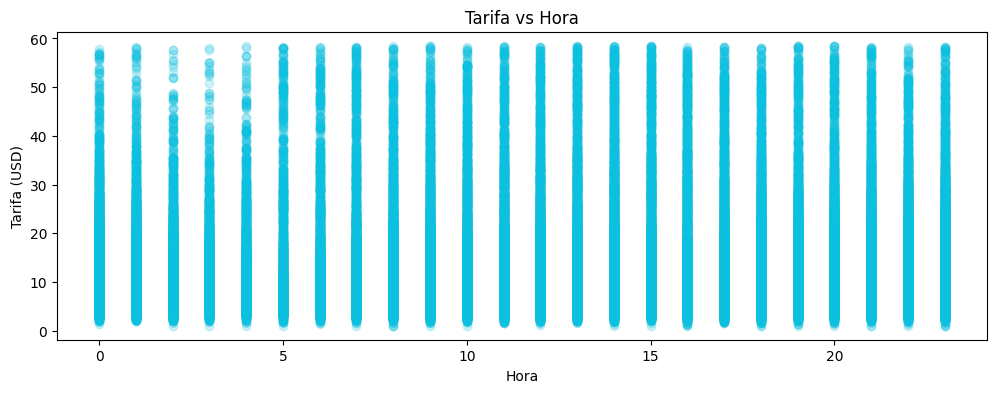

In [222]:
plt.figure(figsize=(12, 4))
plt.scatter(data["hour"], data["fare_amount"], alpha=0.2, color="#0cc0df")
plt.title("Tarifa vs Hora")
plt.xlabel("Hora")
plt.ylabel("Tarifa (USD)")
plt.show()

En estos gráficos no se observa una relación clara entre la cantidad de pasajeros o la hora a la que se realizó el viaje con la tarifa. 

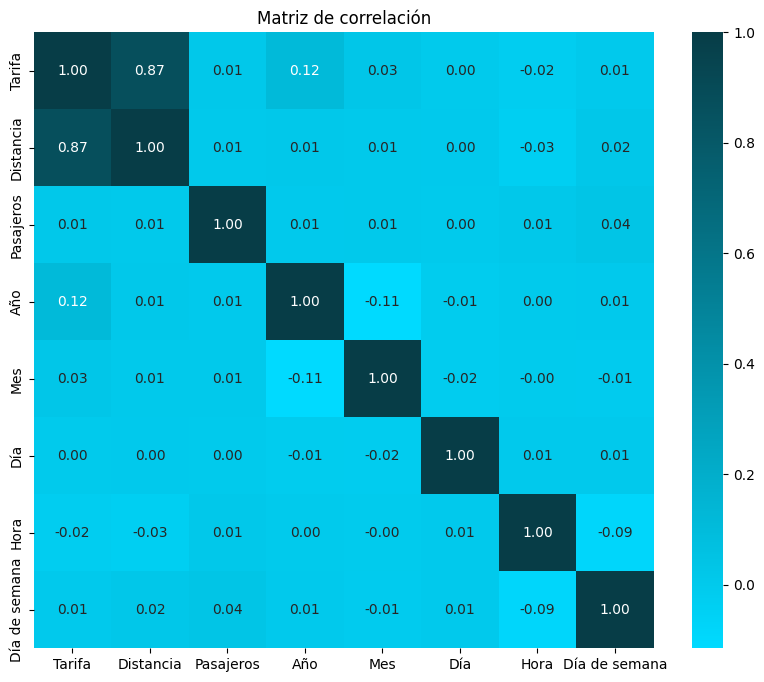

In [223]:
corr_cols = [
    "fare_amount",
    "distance_km",
    "passenger_count",
    "year",
    "month",
    "day",
    "hour",
    "weekday"
]

corr = data[corr_cols].corr(numeric_only=True)

nombres = {
    "fare_amount": "Tarifa",
    "distance_km": "Distancia",
    "passenger_count": "Pasajeros",
    "year": "Año",
    "month": "Mes",
    "day": "Día",
    "hour": "Hora",
    "weekday": "Día de semana"
}

corr = corr.rename(index=nombres, columns=nombres)

cmap_personalizado = LinearSegmentedColormap.from_list(
    "mi_cmap",
    ["#00daff", "#073D47"]
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap=cmap_personalizado, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

En la matriz de correlación se ve bastante claro que la variable con mayor relación lineal con la tarifa es la distancia, con una correlación alta y positiva. Esto era esperable, ya que a mayor distancia recorrida, mayor tiende a ser el costo del viaje. En cambio, el resto de las variables muestran correlaciones bastante bajas con la tarifa, por lo que, al menos de manera lineal, no parecen tener un peso tan fuerte por sí solas.

In [226]:
print(data.shape)

(193226, 14)


A lo largo del análisis detectamos valores faltantes (en dropoff), cantidades de pasajeros no lógicas (0 o 208), coordenadas inexistentes o fuera del rango de interés y algunos valores extremos que podían sumar ruido en variables importantes como la tarifa y la distancia. 

Después de aplicar esta limpieza, pasamos de 200.000 registros a 193.226, es decir, se eliminaron 6.774 filas, que representan alrededor del 3,39% del total. Esto nos deja una base bastante más consistente para seguir trabajando, sin haber perdido una parte grande de la información original.

A su vez, los gráficos y las medidas descriptivas posteriores al recorte nos permiten ver los datos de una forma mucho más clara, y la matriz de correlación termina de resumir qué variables parecen estar más vinculadas con la tarifa. 

Con todo esto, el conjunto de datos final es más consistente y está correctamente preparado para avanzar con la parte de modelado.

# Codificación de variables  
se opta por codificar mediante one-hot las variables de mes, hora y día de semana para que el modelo no interprete que hay alguna relación ordinal entre ellas.

In [ ]:
# #se dropean las columna que no son predictores
# X = data.drop(columns=["fare_amount", "key", "pickup_datetime"])
# y = data["fare_amount"]

# #se codifican las columnas necesarias
# X = pd.get_dummies(X, columns=["month", "weekday", "hour"], drop_first=True)

KeyError: "['pickup_datetime'] not found in axis"

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=66)

In [ ]:
#se escalan los datos
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(156138, 47)
(39035, 47)
